In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl
from hmf import MassFunction

# ------------------------
# CONFIG
# ------------------------
h = 1.0 #1.0
sigma8 = 0.8
Om0 = 0.318
Ob0 = 0.04
n_s = 0.96

z_vals = np.arange(0.1, 1.0 + 1e-9, 0.1)
Mmin_log10, Mmax_log10, dlog10m = 13.0, 16.0, 0.01
log10M_msunh = np.arange(Mmin_log10, Mmax_log10 + 1e-9, dlog10m)
M_msunh = 10**log10M_msunh
M_msun = M_msunh * h  # convert to Msun for CCL
mask = (M_msunh >= 1e13) & (M_msunh <= 1e15)
mask_noh = (M_msun >= 1e13*h) & (M_msun <= 1e15*h)


In [2]:

# ------------------------
# CCL CONFIG
# ------------------------
cosmo_ccl = ccl.Cosmology(
    Omega_c=Om0 - Ob0,
    Omega_b=Ob0,
    h=h,
    n_s=n_s,
    sigma8=sigma8,
    Omega_k=0.0,
    Neff=3.044,
    m_nu=0.0,
    w0=-1.0,
    wa=0.0,
    T_CMB=2.7255,
)

hmf_ccl = ccl.halos.MassFuncTinker08(mass_def='200m')

def dndlnM_ccl(cosmo, M_msun, a):
    dndlog10M = hmf_ccl(cosmo, M_msun, a)  # dn/dlog10M [Mpc^-3]
    return dndlog10M / np.log(10.0)        # convert to dn/dlnM

# compute grid
dndlnM_ccl_arr = np.empty((len(z_vals), len(M_msun)))
for i, z in enumerate(z_vals):
    a = 1.0 / (1.0 + z)
    dndlnM_ccl_arr[i] = dndlnM_ccl(cosmo_ccl, M_msun, a)

# rescale for h units
dndlnM_ccl_h3 = dndlnM_ccl_arr * h**3 # dn/dlnM [h^3 Mpc^-3]; 
#dndlnM_ccl_h3 = dndlnM_ccl_arr * h**3 / h # to convert from dn/dlnM to dn/dlnM_h

# Convert CCL from Msun to Msun/h grid
dndlnM_ccl_h3_interp = np.empty_like(dndlnM_ccl_arr)
for i, z in enumerate(z_vals):
    dndlnM_ccl_h3_interp[i] = np.interp(
        np.log(M_msunh),             # target grid in Msun/h
        np.log(M_msun),              # original CCL grid in Msun
        dndlnM_ccl_h3[i],            # dn/dlnM [h^3 Mpc^-3]
        left=np.nan, right=np.nan
    )


# ------------------------
# HMF CONFIG
# ------------------------
dndlnM_hmf_arr = np.empty_like(dndlnM_ccl_arr)
for i, z in enumerate(z_vals):
    mf = MassFunction(
        z=z,
        cosmo_params={"H0": 100*h, "Om0": Om0, "Ob0": Ob0},
        sigma_8=sigma8,
        n=n_s,
        hmf_model='Tinker08',
        Mmin=Mmin_log10-3, Mmax=Mmax_log10+1, dlog10m=dlog10m,
        mdef_model="SOMean", mdef_params={"overdensity": 200}
    )
    # interpolate to match same mass grid
    dndlnM_hmf_arr[i] = np.interp(np.log(M_msunh), np.log(mf.m), mf.dndlnm)
    m_h = mf.m  # save mass array for plotting
    
# ------------------------
# COSMOSIS RESULTS
# ------------------------
# I got these files from including the module from cosmosis-standard-library/mass_function/mf_tinker and running cosmosis on a config file with the same cosmology as above.

# h=0.7 files
mass_cosmo = np.loadtxt('/global/homes/x/xintang/cosmosis-standard-library/mf_xt/mock_mf/results_mf_z03/mass_function/m_h.txt', comments='#')        # M_h [Msun/h]
dndlnmh_cosmo = np.loadtxt('/global/homes/x/xintang/cosmosis-standard-library/mf_xt/mock_mf/results_mf_z03/mass_function/dndlnmh.txt', comments='#')

'''
# h=1.0 files
mass_cosmo = np.loadtxt('/global/homes/x/xintang/cosmosis-standard-library/mf_xt/mock_mf/results_mf_z01_h1/mass_function/m_h.txt', comments='#')        # M_h [Msun/h]
dndlnmh_cosmo = np.loadtxt('/global/homes/x/xintang/cosmosis-standard-library/mf_xt/mock_mf/results_mf_z01_h1/mass_function/dndlnmh.txt', comments='#')
'''

# Ensure correct shape: (nz, nM)
dndlnmh_cosmo = np.asarray(dndlnmh_cosmo)
if dndlnmh_cosmo.shape[0] < dndlnmh_cosmo.shape[1]:
    dndlnmh_cosmo = dndlnmh_cosmo
    
# Interpolate Cosmosis results to match CCL/HMF mass grid
dndlnM_cosmo_interp = np.empty_like(dndlnM_ccl_arr)
for i, z in enumerate(z_vals):
    dndlnM_cosmo_interp[i] = np.interp(
        np.log(M_msunh),
        np.log(mass_cosmo),
        dndlnmh_cosmo[i],
        left=np.nan, right=np.nan
    )


/global/homes/x/xintang/anaconda3/envs/firecrown_clp/lib/python3.12/site-packages/hmf/density_field/transfer_models.py:232: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  warnings.warn(


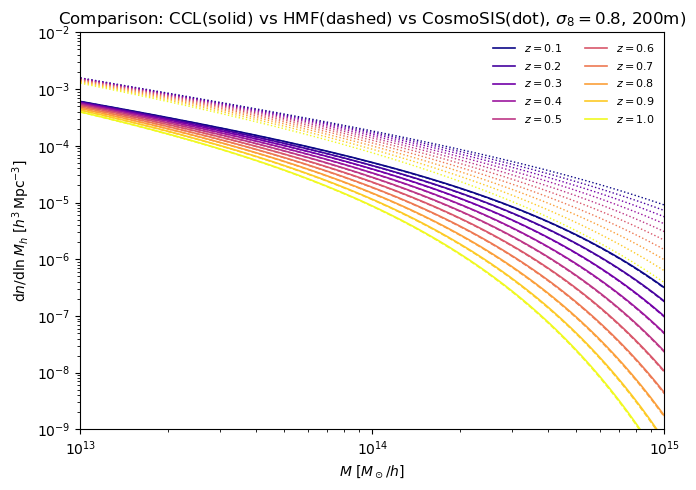

In [3]:
# ------------------------
# PLOT
# ------------------------
fig, ax = plt.subplots(figsize=(7,5))

import matplotlib.cm as cm

colors = cm.plasma(np.linspace(0, 1, len(z_vals)))  


for i, z in enumerate(z_vals):
    # solid = CCL, dashed = HMF
    color = colors[i]
    ax.loglog(M_msunh[mask], dndlnM_ccl_h3_interp[i, mask], '-', lw=1.2, color=color, label=fr'$z={z:.1f}$')
    ax.loglog(M_msunh[mask], dndlnM_hmf_arr[i, mask], '--', lw=1.0, color=color)#, label=fr'HMF $z={z:.1f}$')
    ax.loglog(M_msunh[mask], dndlnM_cosmo_interp[i, mask], ':', lw=1.0, color=color)#, label=fr'CosmoSIS $z={z:.1f}$')

ax.set_xlim(1e13, 1e15)
ax.set_ylim(1e-9, 1e-2)
ax.set_xlabel(r'$M\ [M_\odot/h]$')
ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\ln M_h\ [h^3\,\mathrm{Mpc}^{-3}]$')
ax.set_title(r'Comparison: CCL(solid) vs HMF(dashed) vs CosmoSIS(dot), $\sigma_8=0.8$, 200m)')
ax.legend(ncol=2, fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

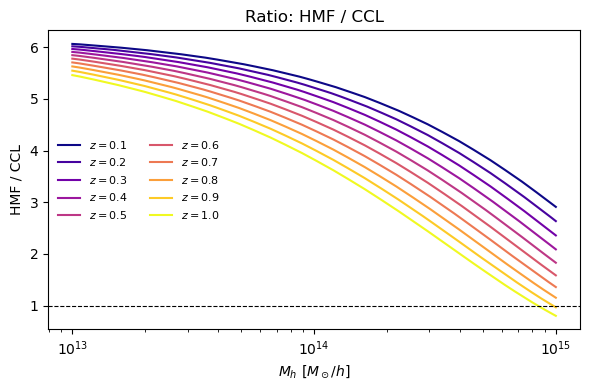

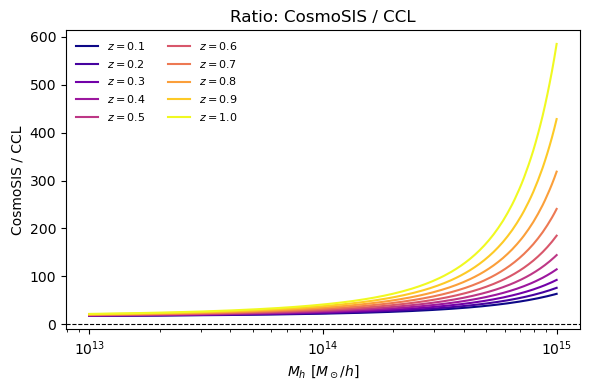

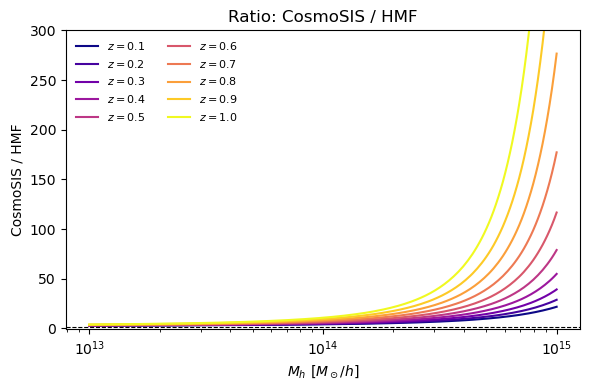

In [8]:
ratio_hmf_ccl    = dndlnM_hmf_arr        / dndlnM_ccl_h3_interp
ratio_cosmo_ccl  = dndlnM_cosmo_interp   / dndlnM_ccl_h3_interp
ratio_cosmo_hmf  = dndlnM_cosmo_interp   / dndlnM_hmf_arr

import matplotlib.cm as cm
colors = cm.plasma(np.linspace(0, 1, len(z_vals)))

# 1) HMF / CCL
fig, ax = plt.subplots(figsize=(6,4))
for i, z in enumerate(z_vals):
    ax.semilogx(M_msunh[mask], ratio_hmf_ccl[i, mask], color=colors[i], label=fr'$z={z:.1f}$')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xlabel(r'$M_h\ [M_\odot/h]$')
ax.set_ylabel('HMF / CCL')
ax.set_title('Ratio: HMF / CCL')
ax.legend(ncol=2, fontsize=8, frameon=False)
fig.tight_layout()

# 2) CosmoSIS / CCL
fig, ax = plt.subplots(figsize=(6,4))
for i, z in enumerate(z_vals):
    ax.semilogx(M_msunh[mask], ratio_cosmo_ccl[i, mask], color=colors[i], label=fr'$z={z:.1f}$')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xlabel(r'$M_h\ [M_\odot/h]$')
ax.set_ylabel('CosmoSIS / CCL')
ax.set_title('Ratio: CosmoSIS / CCL')
ax.legend(ncol=2, fontsize=8, frameon=False)
fig.tight_layout()

# 3) CosmoSIS / HMF
fig, ax = plt.subplots(figsize=(6,4))
for i, z in enumerate(z_vals):
    ax.semilogx(M_msunh[mask], ratio_cosmo_hmf[i, mask], color=colors[i], label=fr'$z={z:.1f}$')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xlabel(r'$M_h\ [M_\odot/h]$')
ax.set_ylabel('CosmoSIS / HMF')
#ax.set_xlim(1e13, 1e14)
ax.set_ylim(-1, 300)
ax.set_title('Ratio: CosmoSIS / HMF')
ax.legend(ncol=2, fontsize=8, frameon=False)
fig.tight_layout()

plt.show()
